In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Đọc dữ liệu đã làm sạch
df = pd.read_csv('cleaned.csv')

# Thống kê các cột số (Quantity, UnitPrice, Revenue)
print(df[['Quantity', 'UnitPrice', 'Revenue']].describe())


C:\Users\toton\AppData\Local\Temp\ipykernel_17636\941263555.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cleaned.csv')


            Quantity      UnitPrice        Revenue
count  524878.000000  524878.000000  524878.000000
mean       10.616600       3.922573      20.275399
std       156.280031      36.093028     271.693566
min         1.000000       0.001000       0.001000
25%         1.000000       1.250000       3.900000
50%         4.000000       2.080000       9.920000
75%        11.000000       4.130000      17.700000
max     80995.000000   13541.330000  168469.600000


In [7]:
# 1. Kiểm tra kích thước dữ liệu (Số dòng, Số cột)
rows, cols = df.shape
print(f"Kích thước dữ liệu sau khi làm sạch: {rows} dòng và {cols} cột.")

Kích thước dữ liệu sau khi làm sạch: 524878 dòng và 12 cột.


In [8]:
# 2. Thống kê số lượng giá trị duy nhất (Unique values) của từng trường
unique_stats = pd.DataFrame({
    'Cột': df.columns,
    'Số giá trị duy nhất': [df[col].nunique() for col in df.columns],
    'Kiểu dữ liệu': [df[col].dtype for col in df.columns]
})

print("\nThống kê giá trị duy nhất trên từng cột:")
print(unique_stats)


Thống kê giá trị duy nhất trên từng cột:
            Cột  Số giá trị duy nhất    Kiểu dữ liệu
0     InvoiceNo                19962          object
1     StockCode                 3922          object
2   Description                 4026          object
3      Quantity                  375           int64
4   InvoiceDate                18499  datetime64[ns]
5     UnitPrice                 1291         float64
6    CustomerID                 4339           int64
7       Country                   38          object
8       Revenue                 4736         float64
9    Month_Year                   13          object
10         Date                  305          object
11         Hour                   15           int64


In [9]:
# 3. Xem nhanh số lượng đơn hàng và khách hàng thực tế
total_invoices = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
total_countries = df['Country'].nunique()

print(f"\n--- Các chỉ số chính ---")
print(f"Tổng số hóa đơn duy nhất: {total_invoices}")
print(f"Tổng số khách hàng duy nhất (bao gồm nhóm '0'): {total_customers}")
print(f"Tổng số quốc gia: {total_countries}")


--- Các chỉ số chính ---
Tổng số hóa đơn duy nhất: 19962
Tổng số khách hàng duy nhất (bao gồm nhóm '0'): 4339
Tổng số quốc gia: 38


In [3]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_countries)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Name: Revenue, dtype: float64


In [4]:

top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
0        1754901.91
14646     280206.02
18102     259657.30
17450     194390.79
16446     168472.50
14911     143711.17
12415     124914.53
14156     117210.08
17511      91062.38
16029      80850.84
Name: Revenue, dtype: float64


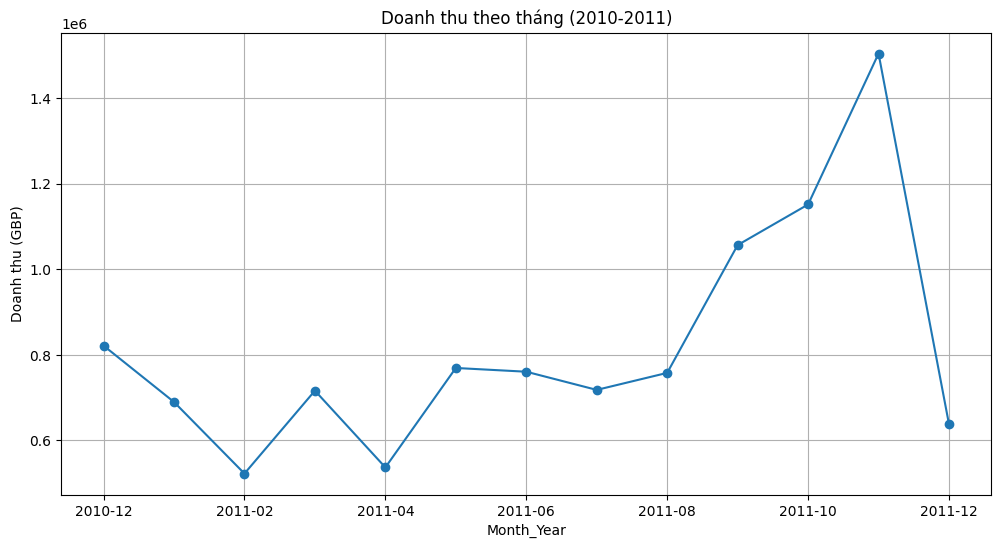

In [5]:
# Chuyển về datetime nếu chưa có
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Doanh thu theo tháng
monthly_revenue = df.groupby('Month_Year')['Revenue'].sum()

# Vẽ biểu đồ nhanh để kiểm tra xu hướng
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Doanh thu theo tháng (2010-2011)')
plt.ylabel('Doanh thu (GBP)')
plt.grid(True)
plt.show()